<a href="https://colab.research.google.com/github/Wayodeni/university/blob/main/ispm/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №5. Формирование календарного плана проекта и управление рисками**



## **Тема дипломного проекта: "Разработка системы сегментации и классификации льда в области, определяемой пользователем"**



### **1. Календарный план проекта (диаграмма Ганта)**



#### **Функция Python для построения диаграммы Ганта:**

In [ ]:
def create_gantt_chart(tasks, title="Диаграмма Ганта", save_path="gantt_chart.png", figsize=(16, 8)):
    """
    Создает и сохраняет диаграмму Ганта в виде таблицы на основе предоставленных данных о задачах.

    Параметры:
    ----------
    tasks : list of dict
        Список словарей, каждый из которых содержит информацию о задаче в формате:
        {"Task": "Название задачи", "Start": "YYYY-MM-DD", "End": "YYYY-MM-DD", "Group": "Группа задачи"}
    title : str, optional
        Заголовок диаграммы
    save_path : str, optional
        Путь для сохранения изображения
    figsize : tuple, optional
        Размер изображения (ширина, высота) в дюймах

    Возвращает:
    -----------
    None (сохраняет изображение и отображает его)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from datetime import datetime, timedelta

    # Создание DataFrame и преобразование дат
    df = pd.DataFrame(tasks)
    df['Start'] = pd.to_datetime(df['Start'])
    df['End'] = pd.to_datetime(df['End'])

    # Определение временного диапазона проекта
    project_start = df['Start'].min().date()
    project_end = df['End'].max().date()
    project_duration = (project_end - project_start).days + 1

    # Создание всех дат проекта
    all_dates = [project_start + timedelta(days=i) for i in range(project_duration)]
    date_labels = [date.strftime('%d-%m') for date in all_dates]

    # Создание длинного формата данных для heatmap
    gantt_data = []
    for i, task in enumerate(df.itertuples()):
        task_start = task.Start.date()
        task_end = task.End.date()
        for date in all_dates:
            is_active = 1 if task_start <= date <= task_end else 0
            gantt_data.append({
                'Task': task.Task,
                'Date': date.strftime('%Y-%m-%d'),
                'Active': is_active,
                'Group': task.Group
            })

    # Преобразование в DataFrame
    gantt_df = pd.DataFrame(gantt_data)

    # Преобразование в матричный формат для heatmap
    gantt_matrix = gantt_df.pivot(index='Task', columns='Date', values='Active')

    # Получение уникальных групп задач
    groups = df['Group'].unique()

    # Создание цветовой схемы для групп
    group_values = {group: i+1 for i, group in enumerate(groups)}

    # Создание матрицы с группами
    group_matrix = np.zeros_like(gantt_matrix.values)
    for i, task in enumerate(gantt_matrix.index):
        group = df[df['Task'] == task]['Group'].values[0]
        group_value = group_values[group]
        active_indices = np.where(gantt_matrix.iloc[i, :] == 1)
        group_matrix[i, active_indices] = group_value

    # Настройка цветовой схемы - исправлено для устранения deprecation warning
    num_colors = len(group_values) + 1
    cmap = plt.colormaps['Paired']  # Используем plt.colormaps вместо plt.cm.get_cmap
    colors = [cmap(i/(num_colors-1)) for i in range(num_colors)]
    custom_cmap = plt.matplotlib.colors.ListedColormap(['white'] + colors[1:])

    # Создание фигуры с дополнительным пространством для легенды
    fig, ax = plt.subplots(figsize=figsize)

    # Создание heatmap с seaborn
    ax = sns.heatmap(group_matrix, cmap=custom_cmap, cbar=False,
                    linewidths=.5, linecolor='gray',
                    xticklabels=date_labels, yticklabels=gantt_matrix.index, ax=ax)

    # Настройка осей
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel('Задача', fontsize=12)

    # Настройка частоты меток по оси X (каждые 7 дней)
    tick_positions = np.arange(0, project_duration, 7)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_dates[pos].strftime('%d-%m-%Y') for pos in tick_positions], rotation=45)

    # Добавление сетки для недель
    for week_pos in tick_positions:
        plt.axvline(x=week_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Добавление легенды вне области графика
    legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[group_values[group]],
                                    edgecolor='gray', label=group)
                      for group in group_values.keys()]

    # Размещаем легенду вне области графика (справа от диаграммы)
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True, shadow=True)

    # Оптимизация размещения
    plt.tight_layout()

    # Сохранение с высоким разрешением
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

#### **Пример диаграммы Гантта:**

При выполнении данного кода будет создана диаграмма Ганта, отображающая все задачи проекта с цветовым кодированием по группам задач и указанием дат начала и окончания.


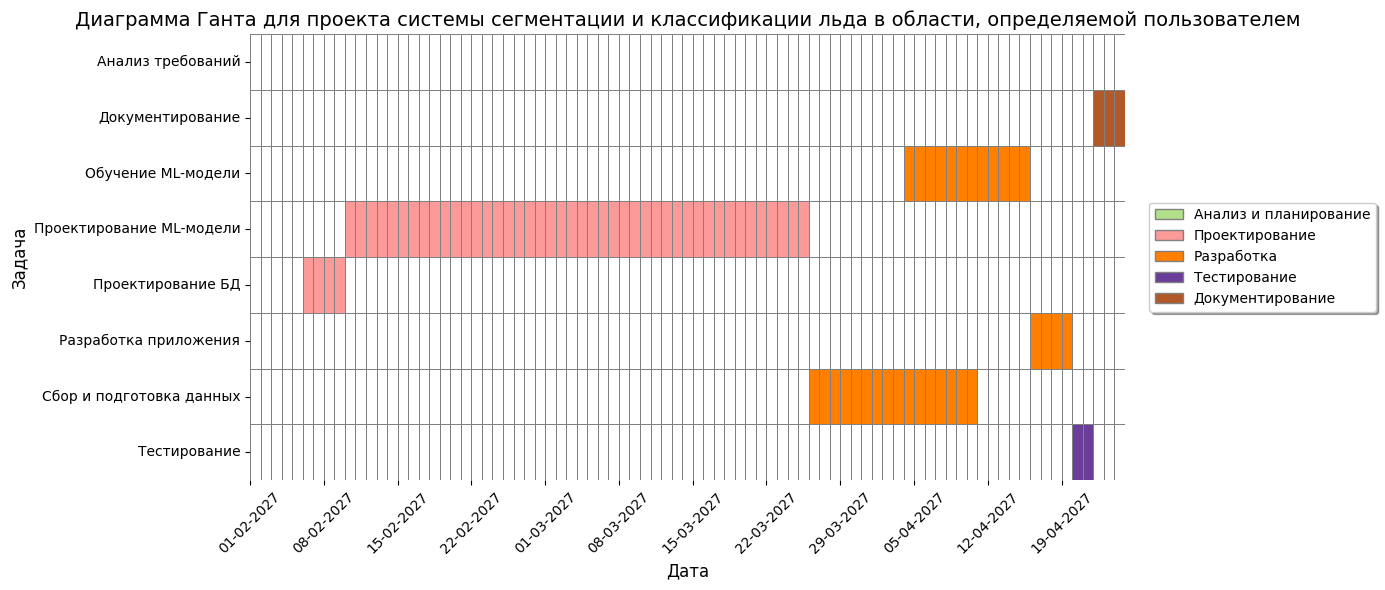

In [ ]:
# Cписок задач по одной-две основные из каждой группы
sample_tasks = [
    {"Task": "Анализ требований", "Start": "2027-02-01", "End": "2025-02-05", "Group": "Анализ и планирование"},

    {"Task": "Проектирование БД", "Start": "2027-02-06", "End": "2027-02-09", "Group": "Проектирование"},
    {"Task": "Проектирование ML-модели", "Start": "2027-02-10", "End": "2027-03-25", "Group": "Проектирование"},

    {"Task": "Сбор и подготовка данных", "Start": "2027-03-26", "End": "2027-04-10", "Group": "Разработка"},
    {"Task": "Обучение ML-модели", "Start": "2027-04-04", "End": "2027-04-15", "Group": "Разработка"},
    {"Task": "Разработка приложения", "Start": "2027-04-16", "End": "2027-04-19", "Group": "Разработка"},

    {"Task": "Тестирование", "Start": "2027-04-20", "End": "2027-04-21", "Group": "Тестирование"},

    {"Task": "Документирование", "Start": "2027-04-22", "End": "2027-04-24", "Group": "Документирование"}
]

# Вызов функции для создания диаграммы Ганта
create_gantt_chart(
    tasks=sample_tasks,
    title="Диаграмма Ганта для проекта системы сегментации и классификации льда в области, определяемой пользователем",
    save_path="gantt_chart_example.png",
    figsize=(14, 6)
)

#### **Задачи проекта:**

| ID  | Задача                    | Длительность (дни) | Предшественники | Начало         | Окончание      |
| --- | ------------------------- | -----------------: | --------------- | -------------- | -------------- |
| 1   | **Анализ и планирование** |              **5** |                 | **01.02.2027** | **05.02.2027** |
| 1.1 | Анализ требований         |                  5 | -               | 01.02.2027     | 05.02.2027     |
| 2   | **Проектирование**        |             **48** |                 | **06.02.2027** | **25.03.2027** |
| 2.1 | Проектирование БД         |                  4 | 1.1             | 06.02.2027     | 09.02.2027     |
| 2.2 | Проектирование ML-модели  |                 44 | 1.1             | 10.02.2027     | 25.03.2027     |
| 3   | **Разработка**            |             **30** |                 | **26.03.2027** | **24.04.2027** |
| 3.1 | Сбор и подготовка данных  |                 16 | 2.2             | 26.03.2027     | 10.04.2027     |
| 3.2 | Обучение ML-модели        |                 12 | 2.2             | 04.04.2027     | 15.04.2027     |
| 3.3 | Разработка приложения     |                  4 | 2.1, 3.2        | 16.04.2027     | 19.04.2027     |
| 4   | **Тестирование**          |              **2** |                 | **20.04.2027** | **21.04.2027** |
| 4.1 | Тестирование              |                  2 | 3.3             | 20.04.2027     | 21.04.2027     |
| 5   | **Документирование**      |              **3** |                 | **22.04.2027** | **24.04.2027** |
| 5.1 | Документирование          |                  3 | 4.1             | 22.04.2027     | 24.04.2027     |


Критический путь выглядит так:

1.1 Анализ требований
→ 2.2 Проектирование ML-модели
→ 3.2 Обучение ML-модели
→ 3.3 Разработка приложения
→ 4.1 Тестирование
→ 5.1 Документирование

Длительность критического пути

1.1 = 5 дней

2.2 = 44 дня

3.2 = 12 дней

3.3 = 4 дня

4.1 = 2 дня

5.1 = 3 дня

Итого: 70 календарных дней

### **2. Анализ и управление рисками проекта**



#### **Таблица анализа рисков:**

| ID  | Риск                                                                       | Вероятность | Влияние | Рейтинг     | Стратегия реагирования | Превентивные меры                                                                                                                                                                |
| --- | -------------------------------------------------------------------------- | ----------- | ------- | ----------- | ---------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| R1  | Недостаточное качество или объём спутниковых данных для обучения модели    | Высокая     | Высокое | Критический | Снижение               | • Проведение раннего аудита доступных датасетов<br>• Использование открытых источников данных ДЗЗ<br>• Применение аугментации данных<br>• Использование предобученных моделей    |
| R2  | Низкая точность сегментации и классификации льда                           | Высокая     | Высокое | Критический | Снижение               | • Подбор и сравнение нескольких архитектур моделей<br>• Валидация на тестовых выборках<br>• Итеративная настройка гиперпараметров<br>• Привлечение экспертной оценки результатов |
| R3  | Зависимость качества результатов от сезона, региона и типа снимков         | Высокая     | Высокое | Критический | Снижение               | • Формирование разнообразной обучающей выборки<br>• Включение данных из разных сезонов и районов<br>• Отдельное тестирование модели на разных типах данных                       |
| R4  | Высокая вычислительная нагрузка при обработке изображений и ROI            | Средняя     | Высокое | Высокий     | Снижение               | • Использование тайлинга изображений<br>• Оптимизация модели<br>• Кэширование результатов<br>• Использование GPU при инференсе                                                   |
| R5  | Ограниченная масштабируемость Streamlit-приложения                         | Средняя     | Высокое | Высокий     | Снижение               | • Разделение UI и backend-логики<br>• Вынос инференса в отдельный сервис<br>• Контейнеризация приложения<br>• Подготовка архитектуры к горизонтальному масштабированию           |
| R6  | Ошибки при работе с геопространственными данными и ROI                     | Средняя     | Высокое | Высокий     | Снижение               | • Проверка корректности координат и геопривязки<br>• Тестирование работы с GeoTIFF и ROI разных типов<br>• Использование проверенных библиотек для геообработки                  |
| R7  | Неправильная интерпретация пользователем результатов анализа               | Средняя     | Высокое | Высокий     | Снижение               | • Добавление пояснений к классам льда и метрикам<br>• Визуализация ограничений модели<br>• Отображение предупреждений о допустимой области применения                            |
| R8  | Ограниченная доступность или неоднородность входных данных ДЗЗ             | Средняя     | Среднее | Средний     | Снижение               | • Поддержка нескольких форматов и источников данных<br>• Использование локального набора тестовых данных<br>• Подготовка сценариев работы с неполными данными                    |
| R9  | Задержки разработки из-за сложности ML-части проекта                       | Высокая     | Среднее | Высокий     | Снижение               | • Разделение проекта на MVP и расширенную версию<br>• Выделение резерва времени на обучение модели<br>• Параллельная разработка интерфейса и ML-модуля                           |
| R10 | Низкое удобство интерфейса для прикладных пользователей                    | Средняя     | Среднее | Средний     | Снижение               | • Проектирование интерфейса по сценарию ROI-first<br>• Упрощение пользовательского пути<br>• Тестирование прототипа на потенциальных пользователях                               |
| R11 | Ошибки интеграции ML-модуля с веб-интерфейсом                              | Средняя     | Среднее | Средний     | Снижение               | • Модульная архитектура системы<br>• Раннее тестирование обмена данными между UI и ML<br>• Использование API-слоя между компонентами                                             |
| R12 | Потеря производительности при работе с крупными спутниковыми изображениями | Средняя     | Высокое | Высокий     | Снижение               | • Ограничение максимального размера входных файлов для MVP<br>• Предварительное ресэмплирование данных<br>• Асинхронная обработка тяжёлых задач                                  |
| R13 | Отсутствие достаточного количества размеченных эталонных данных            | Высокая     | Высокое | Критический | Снижение               | • Использование открытых размеченных наборов<br>• Частичная ручная разметка<br>• Применение semi-supervised/self-supervised подходов                                             |
| R14 | Появление аналогичных функций у существующих платформ                      | Средняя     | Среднее | Средний     | Снижение               | • Фокус на узкой предметной специализации<br>• Развитие уникального сценария ROI + сегментация + статистика<br>• Ускоренное развитие MVP                                         |


### **3. Контрольные точки проекта**


| № | Веха                                 | Дата       | Критерии достижения                                                                                                                                                                                                                                                                  |
| - | ------------------------------------ | ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| 1 | Утверждение технического задания     | 05.02.2027 | • Документ ТЗ согласован с руководителем<br>• Определены цели и границы проекта<br>• Сформулирован перечень функциональных требований<br>• Зафиксированы нефункциональные требования и ограничения системы                                                                           |
| 2 | Завершение проектирования системы    | 25.03.2027 | • Разработана и утверждена архитектура веб-приложения<br>• Спроектирована структура базы данных или модели хранения результатов<br>• Определена архитектура ML-модели сегментации и классификации<br>• Определена структура взаимодействия между UI, ML-модулем и модулем статистики |
| 3 | Завершение подготовки данных         | 10.04.2027 | • Собран и подготовлен набор спутниковых данных для обучения и тестирования<br>• Выполнена предварительная обработка данных<br>• Подготовлены данные для сегментации и классификации льда<br>• Документированы источники данных и структура датасета                                 |
| 4 | Обучение ML-модели                   | 15.04.2027 | • Выполнено обучение модели сегментации и классификации<br>• Получены приемлемые метрики качества на тестовой выборке<br>• Подобраны основные гиперпараметры модели<br>• Задокументированы результаты обучения и показатели качества                                                 |
| 5 | Завершение разработки веб-приложения | 19.04.2027 | • Реализован пользовательский интерфейс Streamlit<br>• Реализована загрузка изображений и выбор ROI<br>• Реализованы запуск сегментации и классификации<br>• Реализован вывод статистики по льду в ROI                                                                               |
| 6 | Интеграция компонентов системы       | 19.04.2027 | • ML-модель интегрирована в веб-приложение<br>• Настроено взаимодействие между интерфейсом, обработкой изображений и модулем статистики<br>• Результаты сегментации и классификации корректно отображаются в интерфейсе<br>• Система запускается без критических ошибок              |
| 7 | Завершение тестирования              | 21.04.2027 | • Проведено функциональное тестирование основных сценариев<br>• Проверена корректность работы с ROI и статистикой<br>• Выполнено тестирование устойчивости к ошибочным входным данным<br>• Исправлены выявленные критические ошибки                                                  |
| 8 | Готовность документации              | 24.04.2027 | • Подготовлено руководство пользователя<br>• Подготовлено техническое описание архитектуры системы<br>• Описаны ограничения и условия использования модели<br>• Подготовлены материалы для демонстрации проекта                                                                      |


### **4. Пояснительная записка**



#### **Обоснование принятых решений**

В представленном календарном плане разработка веб-сервиса для сегментации и классификации ледовой обстановки была разделена на пять основных этапов: анализ и планирование, проектирование, разработка, тестирование и документирование. Такая структура обеспечивает последовательную реализацию всех компонентов системы и соответствует логике создания прикладного программного продукта, включающего как веб-интерфейс, так и модуль машинного обучения.

Отличительной особенностью данного проекта является наличие двух тесно связанных направлений разработки: создание ML-модели для сегментации и классификации льда и разработка веб-приложения на Streamlit. Эти направления частично выполняются параллельно, что позволяет сократить общую длительность проекта, однако требует согласования на этапе интеграции. В частности, проектирование ML-модели и подготовка данных формируют основу для последующего обучения, а разработка интерфейса начинается после того, как становятся понятны формат входных данных, структура результатов и сценарий взаимодействия пользователя с системой.

При планировании проекта особое внимание было уделено рискам, характерным для систем анализа спутниковых данных и ML-проектов в области дистанционного зондирования Земли. К наиболее значимым были отнесены риски, связанные с качеством и объёмом обучающих данных, точностью сегментации и классификации льда, сезонной и региональной изменчивостью ледовых условий, а также вычислительными ограничениями при обработке изображений. С учетом того, что основная ценность разрабатываемой системы заключается в корректности визуальных и количественных результатов анализа, именно риски, влияющие на качество модели, были признаны критическими.

Важным аспектом планирования стало выделение значительного времени на проектирование ML-модели, а также на сбор, подготовку и последующее обучение на спутниковых данных. Такое решение обусловлено тем, что именно этапы, связанные с машинным обучением, чаще всего становятся узким местом в проектах данного типа. Для получения качественной модели недостаточно только выбрать архитектуру — необходимо также подготовить данные, привести их к единому формату, обеспечить корректную разметку или структуру классов, а затем провести обучение и оценку результатов. По этой причине этап проектирования ML-модели был сделан самым продолжительным, а обучение модели выделено в отдельную задачу.

Отдельное внимание было уделено этапу тестирования. В рамках проекта тестирование рассматривается не только как проверка работоспособности интерфейса, но и как оценка корректности обработки ROI, устойчивости системы к ошибочным входным данным и приемлемости качества сегментации и классификации. Это особенно важно для веб-сервиса, который должен быть понятен прикладному пользователю и при этом обеспечивать достаточно точный результат для специалистов предметной области.

Контрольные точки проекта были сформированы таким образом, чтобы отражать завершение наиболее значимых этапов разработки: утверждение технического задания, завершение проектирования, подготовку данных, обучение модели, разработку приложения, интеграцию компонентов, тестирование и документирование. Особая веха выделена для подготовки и обучения ML-модели, что подчеркивает её центральную роль в проекте. Без качественно реализованного модуля сегментации и классификации невозможно обеспечить основную функциональную ценность системы.

Таким образом, принятые решения по структуре календарного плана, распределению задач, выделению контрольных точек и управлению рисками обусловлены спецификой проекта, сочетающего разработку веб-интерфейса и ML-модуля для анализа спутниковых изображений. Выбранный подход позволяет обеспечить реалистичность сроков, логичность этапов разработки и фокус на наиболее критичных компонентах будущей системы.
